<a href="https://colab.research.google.com/github/XaVIIIerg/deep-learning-nlp-coursework/blob/main/Lab_02_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AdvNLP - Lab 2**
## **Fine-tuning of a foundation model for emotion classification**



To start with, we are going to install and import the requiered tools for this lab.

In [ ]:
import datasets
import transformers
import peft
import tqdm
import torch
import pandas
import trl
import evaluate

In [ ]:
import numpy as np

### **Emotion classifier**

#### **Step 1 - Load and explore the dataset**

We will load the emotion dataset from dair-ai from the datasets library. This dataset contains 6 differet emotion labels : sadness, joy, love, anger, fear and surprise. We will use Google Colab for this Lab, so we won't create a subset of the dataset. We will call this dataset ```ds```.

In [ ]:
ds = datasets.load_dataset("dair-ai/emotion", "split")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

split/train-00000-of-00001.parquet:   0%|          | 0.00/1.03M [00:00<?, ?B/s]

split/validation-00000-of-00001.parquet:   0%|          | 0.00/127k [00:00<?, ?B/s]

split/test-00000-of-00001.parquet:   0%|          | 0.00/129k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})


The total size of the dataset is 16 000 + 2 000 + 2 000 = 20 000. 16000 elements in the training part of dataset, 2000 are in the validation one and 2000 are in the test one.

#### **Step 2 - Load GPT-2 with LoRA**

With the ```transformers``` library, we will load a GPT-2 model for sequence classification. Then, we will apply a ```LoRA``` configuration with the PEFT library to reduce the number of trainable parameters. Indeed the training process will be long at step 3, which is why we reduce the number of trainable parameters.


In [ ]:
# 1 - Load GPT-2
from transformers import GPT2ForSequenceClassification, GPT2Tokenizer

model_name = "gpt2"

tokenizer = GPT2Tokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

model = GPT2ForSequenceClassification.from_pretrained(model_name, num_labels=6) # sadness, joy, love, anger, fear, surprise
model.config.pad_token_id = tokenizer.pad_token_id


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.




The ```LoraConfig``` class has differents parameters :    


*   ```task_types``` specifies the names of the modules to apply the adapter to. We will use a task for classification.
*   ```r``` is the rank, the lora attention dimension. With a lower rank, we reduce the number of trainable parameters, which is why we chose ```r=8```.
*   ```lora_alpha``` is for Lora scaling.
*   ```lora_dropout``` is for the dropout, we chose a dropout of 0.1 to avoid overfitting.
*   ```bias``` will be none for this lab.


In [ ]:
# 2 - LoRA
from peft import LoraConfig, get_peft_model, TaskType

lora_config = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=8,
    lora_alpha=16,
    lora_dropout=0.1,
    bias="none"
)

model = get_peft_model(model, lora_config)
model.print_trainable_parameters()

trainable params: 299,520 || all params: 124,743,936 || trainable%: 0.2401


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/layer.py:2285: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


The number of trainable parameters is 299,520, the number of all parameters was of 124,743,936 wich is giving us a trainable percentage of 0.2401. LoRA has well reduced the size of trainable parameters, allowing a faster a training for the step 3 of this lab.

#### **Step 3 - Train the classifier head**
For this step, we will :

1.  **Train** our model with LoRA for the emotion classification. We are going to use the function ```tokenize```to describe our tokenizing strategy and the function ```compute_metrics``` to describe also the used metrics for the ```Trainer```
2.   **Measure** the loss and the accuracy of the trained model
3.   **Describe** the training setup
3.   **Use an untrained model** for the classification
4.   **Compare** the accuracies of these two models.



##### **1 - Training**

In [ ]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
        padding=False,
    )

tokenized = ds.map(tokenize, batched=True, remove_columns=["text"])

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return accuracy_metric.compute(predictions=preds, references=labels)

In [ ]:
from transformers import TrainingArguments, Trainer, DataCollatorWithPadding

training_args = TrainingArguments(
    output_dir="./gpt2-lora-emotion",
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=3e-4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    fp16=True, # GPU
    logging_steps=50,
    report_to="none"
)


trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized["train"],
    eval_dataset=tokenized["validation"],
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
)

trainer.train()
results = trainer.evaluate(tokenized["test"])
print(results)

Epoch,Training Loss,Validation Loss,Accuracy
1,0.376125,0.269190,0.905000
2,0.226784,0.198854,0.926500
3,0.231724,0.182276,0.927000


{'eval_loss': 0.19523093104362488, 'eval_accuracy': 0.918, 'eval_runtime': 2.7912, 'eval_samples_per_second': 716.529, 'eval_steps_per_second': 22.571, 'epoch': 3.0}


##### **2 - Measure**

We obtain an accuracy around 90% with only 0.24% of trainable parameters, thanks to LoRA. There is no overfitting, because ```training loss``` and ```validation loss``` follow the same decrease.

##### **3 - Describe**

We can describe our training setup by listing the different hyperparameters :   


*   **Optimizer** : We have used the default optimizer of the ```Trainer``` class : *AdamW*. Indeed, this is usual for the fine-tunning of the transformers. The uncorrelation between the weight decay of Adam enhances the generalisation process.
*   **Learing rate** : The value of ```3e-4``` was chosen because a high learning rate is necessary to converge in a reasonnable running time.
*   **Epochs** : ```3``` is a value that allows convergence and avoids overfitting. Indeed, the results converge already at the end of the 2nd epoch. The validation loss is ```0.208``` at epoch 2 and is similar at epoch 3 : ```0.192```.
*   **Batch size** : ```16``` for the training and ```32``` for the evaluation is a good trade-off for memory/stability of the results. We have a higher value for the evaluation because there is no backpropagation at this step.
*   **Weight decay** : With a value of ```0.01```, the regularization is usual for LoRA with a lower risk of overfitting.
*   **Max_lenght** : With ```128 tokens```, we set the size of the texts of the dataset, which are short.
*   **LoRA rank** : We set ```r=8``` because this value can catch the patterns in the dataset while keeping 0.24% of the parameters trainable.
*   **LoRA alpha** : We chose a value of 16 to have a ratio of 2 with the rank so that the model won't diverge while still learning relatively quick.we chose a value of 16 to have a ratio of 2 with the rank so that the model won't diverge while still learning relatively quick.



##### **4 - Untrained model**


To demonstrate the performance of our trained model we will compare it to an untrained model. For that, we will create a function ```evaluate_model``` and we will apply it to the trained model and the untrained one.

In [ ]:
from torch.utils.data import DataLoader

def evaluate_model(model, dataset, tokenizer, batch_size=32):
    model.eval()
    device = next(model.parameters()).device

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=DataCollatorWithPadding(tokenizer)
    )

    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            labels = batch.pop("labels")
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = outputs.logits.argmax(dim=-1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels))
    return accuracy

##### **5 - Compare**

In [ ]:
# evaluation of the accuracy over a untrained model
model_untrained = GPT2ForSequenceClassification.from_pretrained("gpt2", num_labels=6)
model_untrained.config.pad_token_id = tokenizer.pad_token_id

acc_before = evaluate_model(model_untrained, tokenized["test"], tokenizer)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
# evaluation of the accuracy over our trained model
acc_after = evaluate_model(model, tokenized["test"], tokenizer)

In [ ]:
# comparaison between the two model
print(f"Accuracy with an untrained model : {acc_before*100:.2f}%")
print(f"Accuracy with an trained model : {acc_after*100:.2f}%")

Accuracy with an untrained model : 29.05%
Accuracy with an trained model : 91.80%


We can conclude that our trained model has far better performances that the untrained one. We don't reach a perfect accuracy but 91% is a satisfying result.

Moreover, the performance of the untrained model is logic, it's like choosing a random category within 3, which is more or less 33% of accuracy.

#### **Step 4 - Evaluate the model**

We are going to evaluate the model by showing the training, evaluation loss, and accuracy over time. We are also going to analyze the classification report at the end of the training. To end with, we will interpret the results of the classification, thanks to the confusion matrix in particular.

In [ ]:
def get_predictions(model, dataset, tokenizer, batch_size=32):
    model.eval()
    device = model.device

    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        collate_fn=DataCollatorWithPadding(tokenizer)
    )

    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in dataloader:
            labels = batch.pop("labels")
            batch = {k: v.to(device) for k, v in batch.items()}
            outputs = model(**batch)
            preds = outputs.logits.argmax(dim=-1).cpu()
            all_preds.extend(preds.numpy())
            all_labels.extend(labels.numpy())

    return np.array(all_labels), np.array(all_preds)

label_names = ["sadness", "joy", "love", "anger", "fear", "surprise"]
y_true, y_pred = get_predictions(model, tokenized["validation"], tokenizer)

##### **Training and evaluation score**

In [ ]:
import pandas as pd

log_history = trainer.state.log_history

# Split train and eval
train_logs = [x for x in log_history if "loss" in x and "eval_loss" not in x]
eval_logs  = [x for x in log_history if "eval_loss" in x]

train_df = pd.DataFrame(train_logs)[["epoch", "loss"]].rename(columns={"loss": "train_loss"})
eval_df  = pd.DataFrame(eval_logs)[["epoch", "eval_loss", "eval_accuracy"]]

log_df = pd.merge(train_df, eval_df, on="epoch", how="outer").sort_values("epoch")
log_df = log_df.round(6)

display(log_df.to_string(index=False))


' epoch  train_loss  eval_loss  eval_accuracy\n  0.05    2.168871        NaN            NaN\n  0.10    1.657425        NaN            NaN\n  0.15    1.471626        NaN            NaN\n  0.20    1.027364        NaN            NaN\n  0.25    0.812899        NaN            NaN\n  0.30    0.680733        NaN            NaN\n  0.35    0.666118        NaN            NaN\n  0.40    0.606022        NaN            NaN\n  0.45    0.583498        NaN            NaN\n  0.50    0.550281        NaN            NaN\n  0.55    0.498442        NaN            NaN\n  0.60    0.461464        NaN            NaN\n  0.65    0.489153        NaN            NaN\n  0.70    0.401600        NaN            NaN\n  0.75    0.414485        NaN            NaN\n  0.80    0.458702        NaN            NaN\n  0.85    0.413483        NaN            NaN\n  0.90    0.367846        NaN            NaN\n  0.95    0.387111        NaN            NaN\n  1.00    0.376125   0.269190         0.9050\n  1.05    0.309219        NaN    

##### **Evaluation Accuracy and Loss**

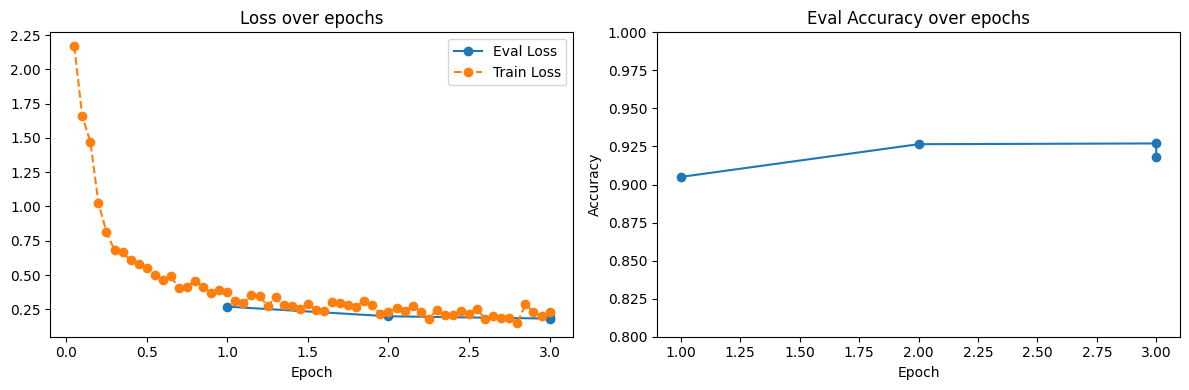

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(eval_df["epoch"], eval_df["eval_loss"],   "o-", label="Eval Loss")
ax1.plot(train_df["epoch"], train_df["train_loss"], "o--", label="Train Loss")
ax1.set_title("Loss over epochs")
ax1.set_xlabel("Epoch")
ax1.legend()

ax2.plot(eval_df["epoch"], eval_df["eval_accuracy"], "o-")
ax2.set_title("Eval Accuracy over epochs")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0.8, 1.0)

plt.tight_layout()
plt.show()

##### **Classification report**

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred, target_names=label_names, digits=4))

              precision    recall  f1-score   support

     sadness     0.9576    0.9436    0.9505       550
         joy     0.9594    0.9389    0.9490       704
        love     0.8519    0.9045    0.8774       178
       anger     0.9140    0.9273    0.9206       275
        fear     0.8657    0.8821    0.8738       212
    surprise     0.8353    0.8765    0.8554        81

    accuracy                         0.9270      2000
   macro avg     0.8973    0.9122    0.9045      2000
weighted avg     0.9281    0.9270    0.9274      2000



##### **Matrix confusion**

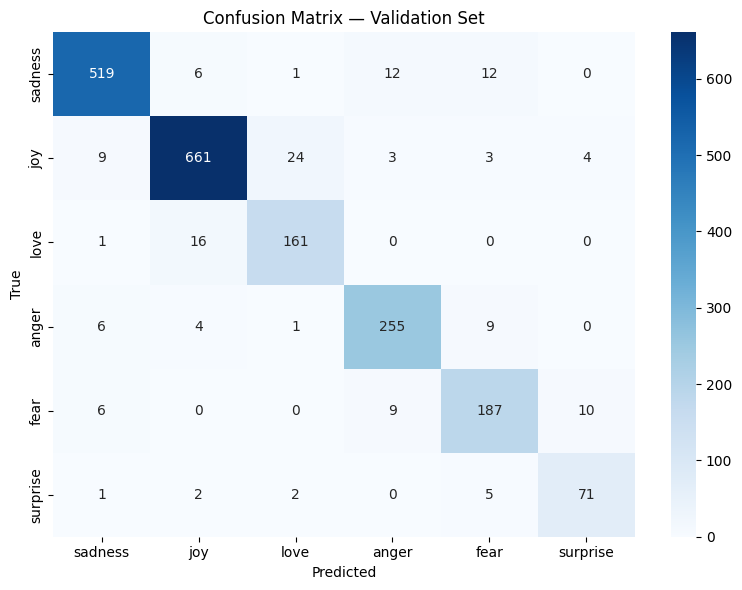

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Validation Set")
plt.tight_layout()
plt.show()

From the differents results, reports, plots and matrix, we can conclude that the model has a good performance to classify each text to the 6 possible emotions. Indeed, the accuracy is around **90%**, which is very satisfying. The model ends with a low loss (< **0.5**) according to the first plot. There is no gap between the training and evaluation curves : there is no overfitting.

The F1 score are high too. We can however denote that some emotions have a lower **F1 score** because they are less represented in the data set (e.g. "fear" and "surprise") : their support are the lowest. This result can also be observed in the confusion matrix where some emotions have lower values on their diagonal. They are "harder" to learn.

"Sadness" and "joy" show very good performance with precision, recall and f1-scores above 0.94. They are the most represented emotions (support > **500**), so they are the "easier" to learn.

The results are satistfying enough to be used during the next Lab.

##### **Step 5 - Export the model**

To conclude this Lab and prepare the next one, we are going to save the fine-tuned model. Because we used Colab, we will store the model in our Google Drive.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from transformers import GPT2Tokenizer, GPT2ForSequenceClassification
from peft import PeftModel
import os

save_path = "/content/drive/MyDrive/4A/gpt2-lora-emotion" # specifique à mon drive

os.makedirs(save_path, exist_ok=True)

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

base_model_for_loading = GPT2ForSequenceClassification.from_pretrained("gpt2", num_labels=6)
base_model_for_loading.config.pad_token_id = base_model_for_loading.config.eos_token_id

loaded_model = PeftModel.from_pretrained(base_model_for_loading, save_path)
loaded_tokenizer = GPT2Tokenizer.from_pretrained(save_path)

print("Model saved in my drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model saved in my drive


To save the model, we have  firstly saved the model (with its adapters for LoRA) and the tokenizer in a chosen folder of our Google Drive, after giving it the right to access with the ```drive.mount()```. Then, the gpt2 and the fine-tuning (peft model) are memorized for a futur loading. Indeed, the objective isn't to save the entire gpt2 model in our Drive. The weight of gpt2 will be charged from HuggingFace Hub for the next Lab. The session will be reinitialized on the Colab but the model will be saved on the Drive, in the folder ```/content/drive/MyDrive/4A/gpt2-lora-emotion```.

In [ ]:
# show a successful model.from_pretrained() call
base_model_for_loading = GPT2ForSequenceClassification.from_pretrained("gpt2", num_labels=6)
base_model_for_loading



Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2ForSequenceClassification LOAD REPORT from: gpt2
Key                  | Status     | 
---------------------+------------+-
h.{0...11}.attn.bias | UNEXPECTED | 
score.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


GPT2ForSequenceClassification(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (score): Linear(in_features=768, out_features=6, bias=False)
)

With the previous cell, we can see that we managed to reload the saved model for the next Lab.